# Agentic RAG with Fallback to Websearch

1. Load the environment variables

In [18]:
import os
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())
OPEN_AI_MODEL_5_NANO='gpt-5-nano'

In [19]:
from haystack.dataclasses import Document
from typing import List, Any, Dict
from haystack.document_stores.in_memory import InMemoryDocumentStore


docs: List[Document] = [
    Document(content="The Indian Premier League (IPL) is a men's Twenty20 (T20) cricket league held annually in India and founded by the BCCI in 2007."),
    Document(content="The league features ten city-based franchise teams playing under a double round-robin and playoffs format."),
    Document(content="The Chennai Super Kings (CSK) and the Mumbai Indians (MI) are the most successful franchises in IPL history, with both teams having won five titles each."),
    Document(content="Virat Kohli is the all-time leading run-scorer in the IPL, while Yuzvendra Chahal is the all-time leading wicket-taker."),
    Document(content="The IPL is the most-attended cricket league in the world and in 2014 was ranked sixth by average attendance among all sports leagues."),
]

document_store = InMemoryDocumentStore()
document_store.write_documents(docs)


5

In [20]:
from haystack.components.builders import ChatPromptBuilder
from haystack.dataclasses import ChatMessage
from haystack.components.generators.chat import OpenAIChatGenerator
from haystack.components.retrievers.in_memory import InMemoryBM25Retriever

retriever = InMemoryBM25Retriever(document_store)

prompt_template = [
    ChatMessage.from_user(
        """
Answer the following query given the documents.
If the answer is not contained within the documents reply with 'no_answer'

Documents:
{% for document in documents %}
  {{document.content}}
{% endfor %}
Query: {{query}}
"""
    )
]

prompt_builder = ChatPromptBuilder(template=prompt_template, required_variables="*")
llm = OpenAIChatGenerator(model=OPEN_AI_MODEL_5_NANO)


In [21]:
from haystack.components.websearch.serper_dev import SerperDevWebSearch

prompt_for_websearch = [
    ChatMessage.from_user(
        """
Answer the following query given the documents retrieved from the web.
Your answer should indicate that your answer was generated from websearch.

Documents:
{% for document in documents %}
  {{document.content}}
{% endfor %}

Query: {{query}}
"""
    )
]

websearch = SerperDevWebSearch()
prompt_builder_for_websearch = ChatPromptBuilder(template=prompt_for_websearch, required_variables="*")
llm_for_websearch = OpenAIChatGenerator(model=OPEN_AI_MODEL_5_NANO)


In [22]:
from haystack.components.routers import ConditionalRouter

routes = [
    {
        "condition": "{{'no_answer' in replies[0].text}}",
        "output": "{{query}}",
        "output_name": "go_to_websearch",
        "output_type": str,
    },
    {
        "condition": "{{'no_answer' not in replies[0].text}}",
        "output": "{{replies[0].text}}",
        "output_name": "answer",
        "output_type": str,
    },
]

router = ConditionalRouter(routes)

In [23]:
from haystack import Pipeline

agentic_rag_pipe = Pipeline()
agentic_rag_pipe.add_component("retriever", retriever)
agentic_rag_pipe.add_component("prompt_builder", prompt_builder)
agentic_rag_pipe.add_component("llm", llm)
agentic_rag_pipe.add_component("router", router)
agentic_rag_pipe.add_component("websearch", websearch)
agentic_rag_pipe.add_component("prompt_builder_for_websearch", prompt_builder_for_websearch)
agentic_rag_pipe.add_component("llm_for_websearch", llm_for_websearch)

agentic_rag_pipe.connect("retriever", "prompt_builder.documents")
agentic_rag_pipe.connect("prompt_builder.prompt", "llm.messages")
agentic_rag_pipe.connect("llm.replies", "router.replies")
agentic_rag_pipe.connect("router.go_to_websearch", "websearch.query")
agentic_rag_pipe.connect("router.go_to_websearch", "prompt_builder_for_websearch.query")
agentic_rag_pipe.connect("websearch.documents", "prompt_builder_for_websearch.documents")
agentic_rag_pipe.connect("prompt_builder_for_websearch", "llm_for_websearch")


🚅 Components
  - retriever: InMemoryBM25Retriever
  - prompt_builder: ChatPromptBuilder
  - llm: OpenAIChatGenerator
  - router: ConditionalRouter
  - websearch: SerperDevWebSearch
  - prompt_builder_for_websearch: ChatPromptBuilder
  - llm_for_websearch: OpenAIChatGenerator
🛤️ Connections
  - retriever.documents -> prompt_builder.documents (list[Document])
  - prompt_builder.prompt -> llm.messages (list[ChatMessage])
  - llm.replies -> router.replies (list[ChatMessage])
  - router.go_to_websearch -> websearch.query (str)
  - router.go_to_websearch -> prompt_builder_for_websearch.query (str)
  - websearch.documents -> prompt_builder_for_websearch.documents (list[Document])
  - prompt_builder_for_websearch.prompt -> llm_for_websearch.messages (list[ChatMessage])

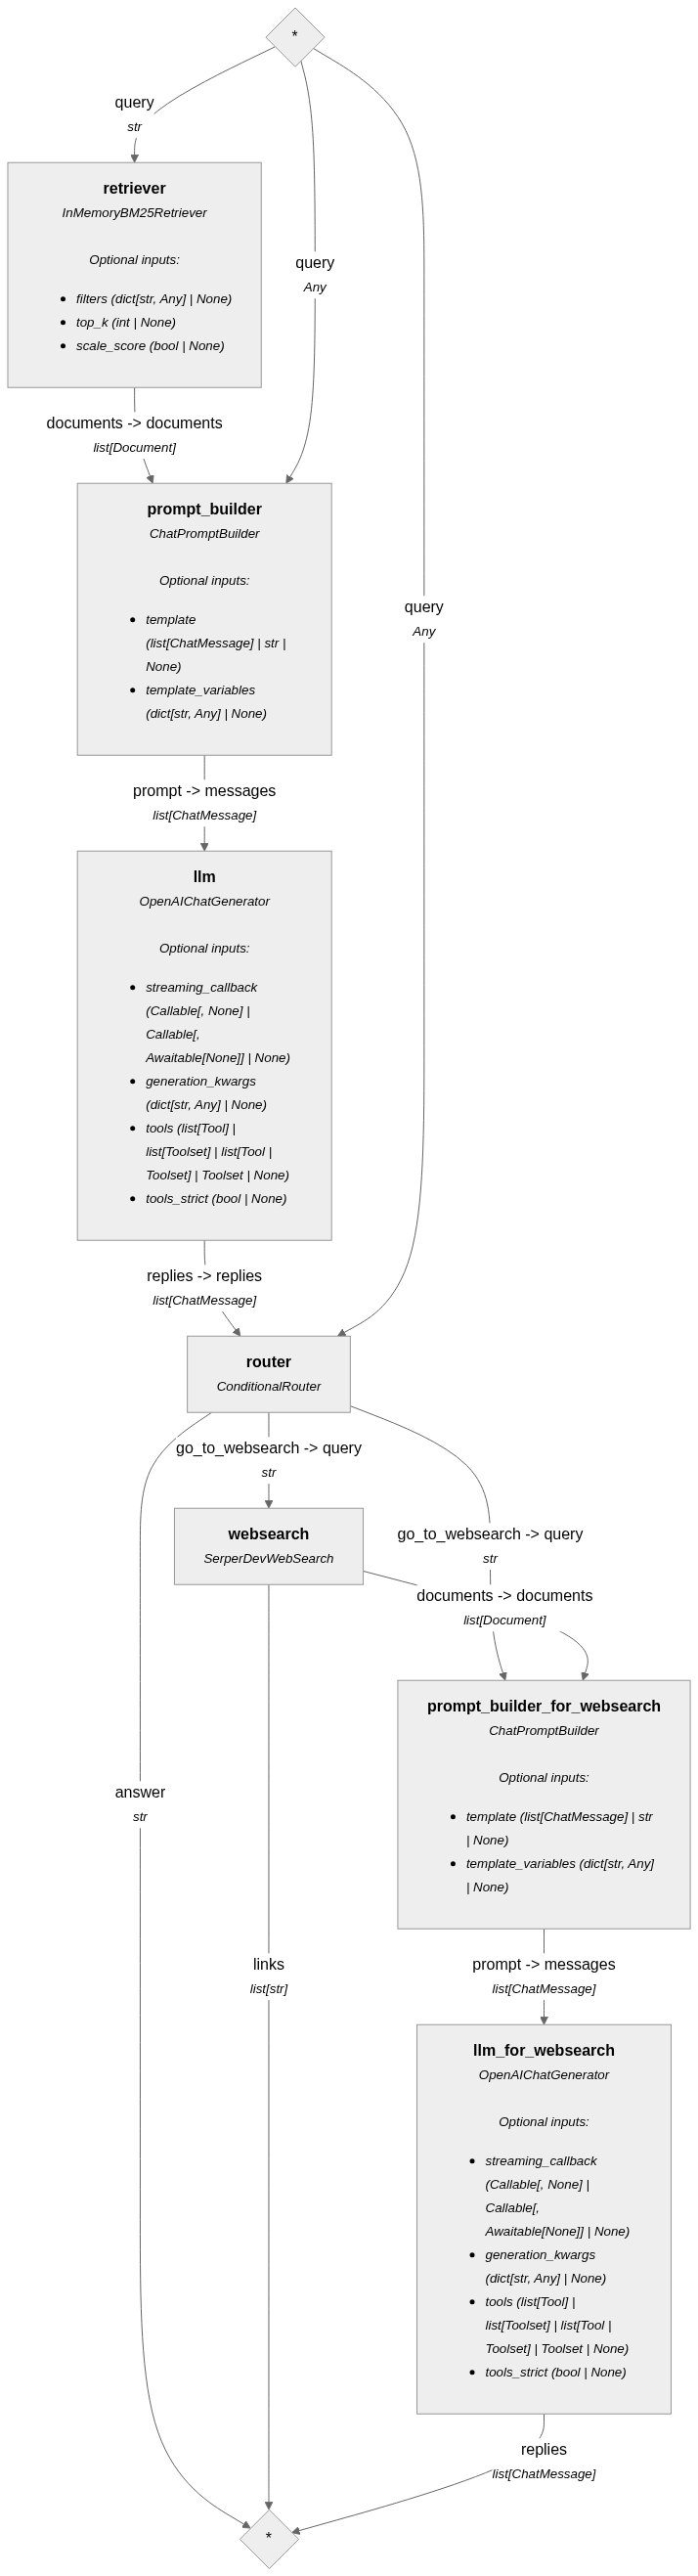

In [ ]:
# agentic_rag_pipe.show()

In [24]:
query = "Who is the top scorer in IPL?"

result = agentic_rag_pipe.run(
    {"retriever": {"query": query}, "prompt_builder": {"query": query}, "router": {"query": query}}
)

# Print the `answer` coming from the ConditionalRouter
print(result["router"]["answer"])


Virat Kohli


In [34]:
query = "Who are the top scorers in IPL 2026 so far?"

result = agentic_rag_pipe.run(
    {"retriever": {"query": query}, "prompt_builder": {"query": query}, "router": {"query": query}}
)

print(result["llm_for_websearch"]["replies"][0].text)


Generated from websearch.

Top run-scorers in IPL 2026 so far:
- Shubman Gill (GT) – 251 runs
- Virat Kohli (RCB) – 228 runs
- Heinrich Klaasen (SRH) – 224 runs
- Rajat Patidar (RCB) – 222 runs

(Source materials note these figures as the leading totals in mid-April 2026.)


In [47]:
import gradio as gr

def get_answer(query):
    try:
        result = agentic_rag_pipe.run(
            {"retriever": {"query": query}, "prompt_builder": {"query": query}, "router": {"query": query}}
        )
        
        if "router" in result and "answer" in result["router"]:
            ans = result["router"]["answer"]
        elif "llm_for_websearch" in result and "replies" in result["llm_for_websearch"]:
            ans = result["llm_for_websearch"]["replies"][0].text
        else:
            ans = "⚠️ Sorry, I could not find an answer."
        
        # Make the answer bold using Markdown
        return f"**{ans}**"
        
    except Exception as e:
        return f"**❌ An error occurred: {str(e)}**"

custom_css = """
footer {visibility: hidden}
.container {max-width: 900px; margin: auto; padding-top: 2rem;}
.header-text {text-align: center; margin-bottom: 2rem;}

/* The Background for the answer area with forced text color */
#ans-box {
    background-color: #e3efff !important; /* Slightly deeper blue for contrast */
    border-radius: 10px; 
    padding: 20px; 
    border-left: 6px solid #004ba0;
    color: #002d62 !important; /* Force dark blue text */
}

/* Ensure text is visible even if the user is in Dark Mode */
.dark #ans-box {
    background-color: #1a2a40 !important; /* Darker navy for dark mode */
    color: #ffffff !important; /* White text for dark mode */
    border-left: 6px solid #ff822a; /* Orange accent for dark mode contrast */
}

/* Style the bold text specifically to ensure it inherits the color */
#ans-box strong {
    color: inherit !important;
}
"""

with gr.Blocks(css=custom_css, theme=gr.themes.Soft(primary_hue="blue")) as demo:
    with gr.Column(elem_classes="container"):
        gr.Markdown(
            '''
            # 🏏 IPL Intelligence Agent
            ### Agentic RAG powered by Haystack
            ''',
            elem_classes="header-text"
        )
        
        with gr.Row():
            with gr.Column(scale=4):
                user_input = gr.Textbox(
                    show_label=False,
                    placeholder="Ask about IPL stats...",
                    container=False
                )
            with gr.Column(scale=1, min_width=100):
                submit_btn = gr.Button("Ask Agent", variant="primary")

        with gr.Row():
            output_display = gr.Markdown(
                elem_id="ans-box",
                value="Waiting for your question..."
            )

        gr.Examples(
            examples=[
                "Leading run scorer in IPL history",
                "Most wickets in IPL history.",
                "Who won the first ever IPL season?",
                "Current wicket keeper of Chennai Super Kings",
                "What is Virat Kohli's total IPL runs?"],
            inputs=user_input
        )

    submit_btn.click(fn=get_answer, inputs=user_input, outputs=output_display, show_progress="circle")
    user_input.submit(fn=get_answer, inputs=user_input, outputs=output_display, show_progress="circle")

if __name__ == "__main__":
    demo.launch()

/var/folders/h7/gyf27_xx5qj9w7293_58p58c0000gn/T/ipykernel_95111/2664209893.py:49: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft(primary_hue="blue")) as demo:


* Running on local URL:  http://127.0.0.1:7878
* To create a public link, set `share=True` in `launch()`.


In [33]:
import gradio as gr

def get_answer(query):
    result = agentic_rag_pipe.run(
        {"retriever": {"query": query}, "prompt_builder": {"query": query}, "router": {"query": query}}
    )
    
    if "router" in result and "answer" in result["router"]:
        return result["router"]["answer"]
    elif "llm_for_websearch" in result and "replies" in result["llm_for_websearch"]:
        return result["llm_for_websearch"]["replies"][0].text
    else:
        return "Sorry, I could not find an answer."

iface = gr.Interface(
    fn=get_answer,
    inputs=gr.Textbox(lines=2, placeholder="Enter your question here..."),
    outputs=gr.Markdown(),
    title="Agentic RAG with HayStack",
    description=">>>> Ask questions about IPL. If the local documents don't have the answer, it will fallback to web search. ||||"
)

iface.launch()

* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.
